機械学習を使ってフェイクニュースかどうかを判別する<br>
使用したデータセット
https://www.kaggle.com/datasets/emineyetm/fake-news-detection-datasets?resource=download <br>
各ツールをインストール -> pip install pandas scikit-learn matplot

In [63]:
#FakeとTrueのデータセットを結合して、FakeNewsdataset.csvという新しいファイルを作成するコード
import pandas as pd

fake = pd.read_csv('../Data/Fake.csv')
fake['label'] = 'fake' #fakeデータにラベルを追加

true = pd.read_csv('../Data/True.csv')
true['label'] = 'true' #trueデータにラベルを追加

df = pd.concat([fake, true], ignore_index=True) #fakeとtrueのデータを結合してDataFrameに変換
df.to_csv('../Data/FakeNewsdataset.csv', index=False) #csvファイルをDataディレクトリに保存

結合したデータセットを読み込んで、学習用データとテスト用データに分割

In [64]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("../Data/FakeNewsdataset.csv", quotechar='"', sep=",") #結合したデータセットを読み込む

texts = df_unique["text"] #テキスト列を抽出
label = df_unique["label"] #ラベル列を抽出

x_train, x_test, y_train, y_test = train_test_split(texts, label, test_size=0.2, random_state=2) #データセットを訓練用とテスト用に分割

print(x_train.head()) #訓練用の先頭データを表示
print(y_train.head())

6896     Trump made a visit to the Keystone State in an...
43309    DUBAI (Reuters) - Iran will not be bullied by ...
29193    WASHINGTON (Reuters) - A veteran CIA clandesti...
26972    WASHINGTON (Reuters) - A political feud erupte...
14510    Tell us again Barack, about the  poor widows a...
Name: text, dtype: str
6896     fake
43309    true
29193    true
26972    true
14510    fake
Name: label, dtype: str


テキストデータの前処理をそれぞれ実行<br>
nltkをコマンドでインストール -> pip install nltk<br>
nltk.download("stopwords")を一回実行

In [65]:
import re
from nltk.corpus import stopwords


def NormalizeText(text):
    text = text.lower() #テキストを小文字変換
    text = text.replace('\n', ' ') #改行をスペースに置換
    text = re.sub(r'[^\w\s]', '', text) #特殊文字を削除
    text = str.strip(text) #テキストの前後の空白を削除
    return text

def TokenizeText(text):
    tokens = text.split() #テキストをスペースで分割してトークン化
    return tokens

def StopWordRemoval(tokens):
    stop_words = set(stopwords.words('english')) #英語のストップワードを取得
    filtered_tokens = [word for word in tokens if word not in stop_words] #ストップワードを除去
    return filtered_tokens

x_train_Normalized = x_train.apply(NormalizeText) #訓練用テキストを正規化
x_train_Tokenized = x_train_Normalized.apply(TokenizeText) #訓練用テキストをトークン化
x_train_Filtered = x_train_Tokenized.apply(StopWordRemoval) #ストップワードを除去

x_test_Normalized = x_test.apply(NormalizeText) #テスト用も同様に処理
x_test_Tokenized = x_test_Normalized.apply(TokenizeText)
x_test_Filtered = x_test_Tokenized.apply(StopWordRemoval)

x_train_Filtered.head() #処理された訓練用テキストの先頭データを表示


6896     [trump, made, visit, keystone, state, effort, ...
43309    [dubai, reuters, iran, bullied, united, states...
29193    [washington, reuters, veteran, cia, clandestin...
26972    [washington, reuters, political, feud, erupted...
14510    [tell, us, barack, poor, widows, orphans, stra...
Name: text, dtype: object

labelのデータをfake,trueから0,1に変換

In [66]:
def map_label(label):
    if label == 'fake':
        return 0
    else:
        return 1

y_train_mapped = y_train.apply(map_label) #ラベルを数値に変換

y_test_mapped = y_test.apply(map_label) #テスト用のラベルも同様に変換

y_train_mapped.head() #変換された訓練用ラベルの先頭データを表示

6896     0
43309    1
29193    1
26972    1
14510    0
Name: label, dtype: int64

前処理をしたx_train_Filteredを使って語彙についてのマッピングをする。

In [60]:
from collections import Counter

vocab = Counter([word for tokens in x_train_Filtered for word in tokens]) #訓練用テキストの単語の出現頻度をカウント
vocab = [word for word, count in vocab.items() if count >= 5]  #出現した中で５回以上出現したものだけにする
word2idx = {word: i for i, word in enumerate(vocab)} 

文章をベクトル化(Bag of Words)

In [112]:
import numpy as np

def bow_vector(tokens):
    vec = np.zeros(len(vocab))
    for word in tokens:
        if word in word2idx:
            vec[word2idx[word]] += 1
    return vec

x_train_vec = np.array([bow_vector(tokens) for tokens in x_train_Filtered])
x_test_vec = np.array([bow_vector(tokens) for tokens in x_test_Filtered])

ロジスティック回帰で分類

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf = LogisticRegression(max_iter=2000)
clf.fit(x_train_vec, y_train)

y_pred = clf.predict(x_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        fake       1.00      0.99      0.99      3472
        true       0.99      1.00      0.99      4258

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



以上の学習では精度があまりにも精度が高すぎる。

In [44]:
set_train = set([" ".join(tokens) for tokens in x_train_Filtered])
set_test = set([" ".join(tokens) for tokens in x_test_Filtered])

len(set_train & set_test)


9

学習データと検証用データの重複があったため、データ読み込みのときにデータの重複を消去する処理を加える

In [47]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("../Data/FakeNewsdataset.csv", quotechar='"', sep=",") #結合したデータセットを読み込む
df_unique = df.drop_duplicates(subset=['text']) #追加 : 重複をなくしたデータにする
texts = df_unique["text"] #テキスト列を抽出
label = df_unique["label"] #ラベル列を抽出

x_train, x_test, y_train, y_test = train_test_split(texts, label, test_size=0.2, random_state=2) #データセットを訓練用とテスト用に分割

print(x_train.head()) #訓練用の先頭データを表示
print(y_train.head())

6896     Trump made a visit to the Keystone State in an...
43309    DUBAI (Reuters) - Iran will not be bullied by ...
29193    WASHINGTON (Reuters) - A veteran CIA clandesti...
26972    WASHINGTON (Reuters) - A political feud erupte...
14510    Tell us again Barack, about the  poor widows a...
Name: text, dtype: str
6896     fake
43309    true
29193    true
26972    true
14510    fake
Name: label, dtype: str


以上の重複を除いてもまだ精度が高い

マッピングされた語彙の数を見る

In [61]:
len(vocab)

42284

５回以上出現する語彙だけで40000を超えているため、マッピングを制限する

In [ ]:
from collections import Counter

vocab_counter = Counter([word for tokens in x_train_Filtered for word in tokens]) #訓練用テキストの単語の出現頻度をカウント
vocab_top = vocab_counter.most_common(9) #上位5000語を取得
vocab = [word for word, count in vocab_top] #単語を取り出す
word2idx = {word: i for i, word in enumerate(vocab)} 

結果は制限する前とほぼ変わらなかったが、学習の処理時間が1/8程度になったため制限をした方が良い。
どれほど制限すれば精度が下がるのかを検証した結果が以下

<function matplotlib.pyplot.show(close=None, block=None)>

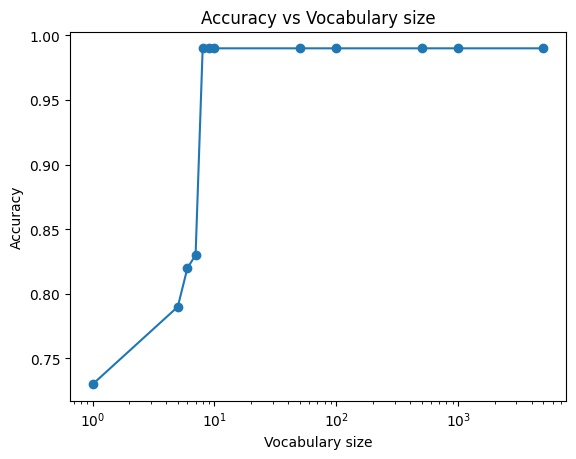

In [114]:
import matplotlib.pyplot as plt

vocab_sizes = [1,5,6,7,8,9,10,50,100,500,1000,5000]
accuracies = [0.73,0.79,0.82,0.83,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99]

plt.plot(vocab_sizes, accuracies, marker="o")
plt.xlabel("Vocabulary size")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Vocabulary size")
plt.xscale("log")
plt.show

上の結果から8語目で急激に精度が向上している。それ以上語彙を追加しても精度は向上しない。